### Rover simulation
##### Load packages and required functions

In [1]:
# load packages
import numpy as np
import roversim
import os
import glob
import sys
import contextlib
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

@contextlib.contextmanager
def suppress_stdout():
    with open(os.devnull, 'w') as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout

def simulation_with_controller_webserver(N, tf = 20, dt = 0.1, fidelity = 1, attack_scenario = 0, parameter_file = "rover_parameters.json", fmu_gen = False):
    sim = roversim.MFRoverClosedSIM(fidelity = fidelity, attack_scenario = attack_scenario, parameter_file = parameter_file, fmu_gen = fmu_gen)
    destination = os.path.join(os.getcwd(), f"results/scenario{attack_scenario}")

    if not os.path.exists(destination):
        os.makedirs(destination)

    for idx in range(N):
        file_path = os.path.join(destination, f"simulation_{idx+1}.csv")
        if os.path.isfile(file_path):
            os.remove(file_path)
        df = sim.simulate(tf = tf, dt = dt)
        df.to_csv(file_path, index=False)
        sim.sim_reset()


    # fidelity: 1 = low-fidelity, 2 = high-fidelity
    # attack_scneario: 0 = no-attack, 1 = emi-attack, 2 = rollover-attack
    #                  3 = gyro acoustic-noise-attack, 4 = emi-vulnerability
    # note: emi-vulnerability is only supported in high fidelity model

##### No-attack nominal case simulation (Scenario 0)
Simulation time: 30 seconds <br/>
Monte-Carlo simulation: No, because the rover maneuvers following the given logic and no uncertanties assumed in the sensor measurements <br/>
Parameters: Default (Check rover_parameters.json) <br/>
Number of simulations: 1 <br/>
Fidelity level: Cyber model (Lo-Fi) + Physics model (Hi-Fi)

In [3]:
param_file = Path("rover_parameters.json").absolute()

verbose = True

if verbose:
    simulation_with_controller_webserver(N = 1, tf = 30, attack_scenario = 0, fidelity = 2, parameter_file=param_file, fmu_gen = False)
else:
    with suppress_stdout():
        simulation_with_controller_webserver(N = 1, tf = 30, attack_scenario = 0, fidelity = 2, parameter_file=param_file, fmu_gen = False)

Final Run Statistics: --- 

 Number of steps                                 : 11
 Number of function evaluations                  : 14
 Number of Jacobian evaluations                  : 1
 Number of function eval. due to Jacobian eval.  : 1
 Number of error test failures                   : 0
 Number of nonlinear iterations                  : 11
 Number of nonlinear convergence failures        : 0

Solver options:

 Solver                   : CVode
 Linear multistep method  : BDF
 Nonlinear solver         : Newton
 Linear solver type       : DENSE
 Maximal order            : 5
 Tolerances (absolute)    : 1e-06
 Tolerances (relative)    : 1e-06

Simulation interval    : 0.0 - 0.1 seconds.
Elapsed simulation time: 0.010449833000052422 seconds.
Final Run Statistics: --- 

 Number of steps                                 : 11
 Number of function evaluations                  : 14
 Number of Jacobian evaluations                  : 1
 Number of function eval. due to Jacobian eval.  : 1
 Numb

number of result files: 1, plotting ... 


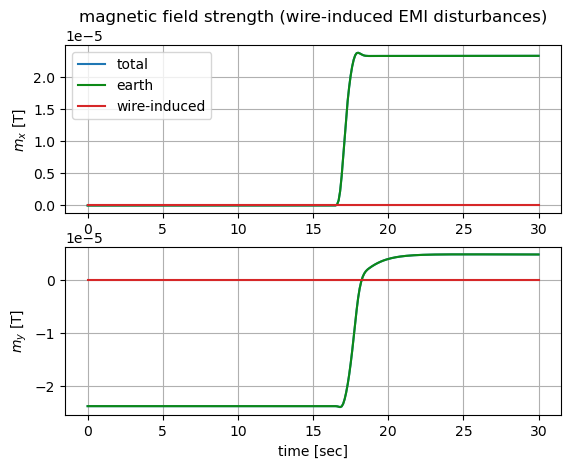

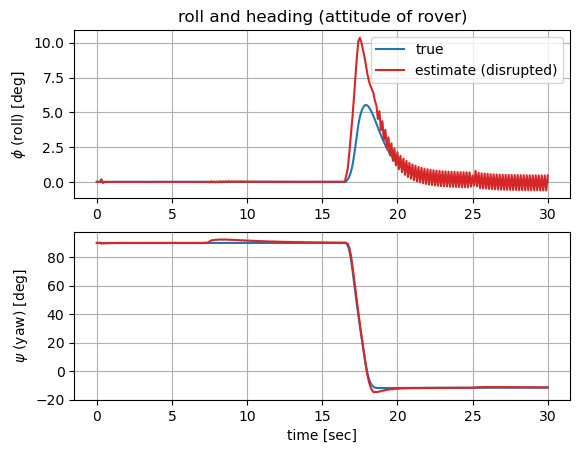

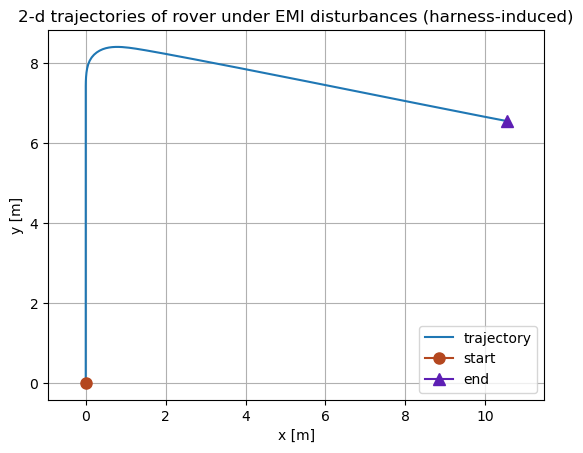

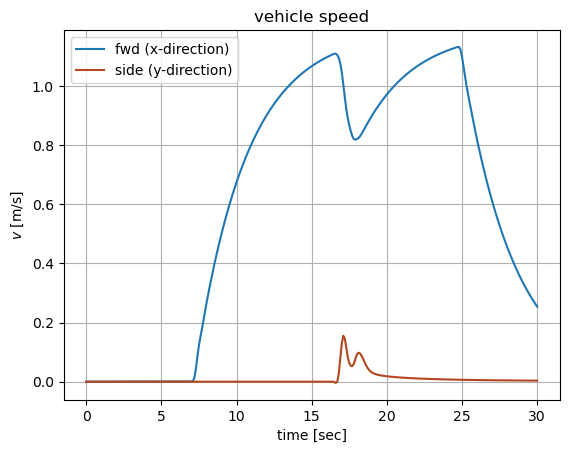

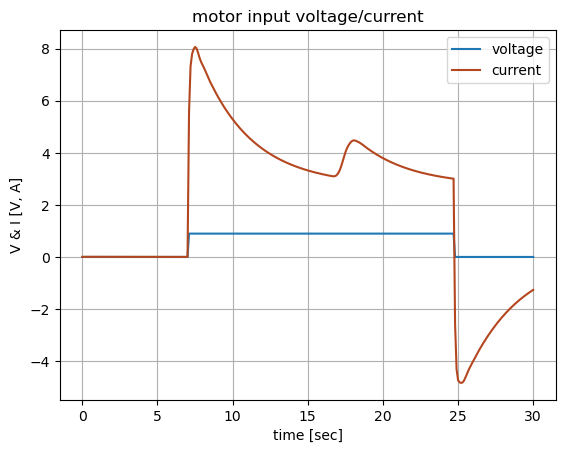

In [3]:
attack_scenario = 0
log_files = glob.glob(os.path.join(os.getcwd(), f"results/scenario{attack_scenario}/*.csv"))
print(f"number of result files: {len(log_files)}, plotting ... ")

if len(log_files) == 1:
    df = pd.read_csv(log_files[0])

    plt.figure()
    plt.subplot(2,1,1)
    plt.plot(np.array(df['time']), np.array(df['mx_meas']), color = '#1f77b4', label = 'total')
    plt.plot(np.array(df['time']), np.array(df['rover_8d.mag.b_earth[1]']), color = "#0d8917", label= 'earth')
    plt.plot(np.array(df['time']), np.array(df['rover_8d.emi.b_wire[1]']), color = "#d62728", label= 'wire-induced')
    plt.grid()
    plt.ylabel(r'$m_{x}$ [T]')
    plt.ticklabel_format(axis='y', style='sci', scilimits=(0,4))
    plt.legend()
    plt.title('magnetic field strength (wire-induced EMI disturbances)')
    plt.subplot(2,1,2)
    plt.plot(np.array(df['time']), np.array(df['my_meas']), color = '#1f77b4')
    plt.plot(np.array(df['time']), np.array(df['rover_8d.mag.b_earth[2]']), color = "#0d8917")
    plt.plot(np.array(df['time']), np.array(df['rover_8d.emi.b_wire[2]']), color = "#d62728")
    plt.grid()
    plt.ylabel(r'$m_{y}$ [T]')
    plt.xlabel('time [sec]')

    plt.figure()
    plt.subplot(2,1,1)
    plt.plot(np.array(df['time']), np.array(df['phi_meas'])/np.pi*180, color = "#1f77b4", label = 'true')
    plt.plot(np.array(df['time']), np.array(df['euler_filtered[1]'])/np.pi*180, color = "#d62728", label = 'estimate (disrupted)')
    plt.grid()
    plt.ylabel(r'$\phi$ (roll) [deg]')
    plt.legend()
    plt.title('roll and heading (attitude of rover)')
    plt.subplot(2,1,2)
    plt.plot(np.array(df['time']), np.array(df['psi_meas'])/np.pi*180, color = "#1f77b4")
    plt.plot(np.array(df['time']), np.array(df['psi_filtered'])/np.pi*180, color = "#d62728")
    plt.grid()
    plt.ylabel(r'$\psi$ (yaw) [deg]')
    plt.xlabel('time [sec]')

    plt.figure()
    plt.plot(np.array(df['x_meas']), np.array(df['y_meas']), color = '#1f77b4', label='trajectory')
    plt.plot(np.array(df['x_meas'].iloc[0]), np.array(df['y_meas'].iloc[0]), color = "#b4471f", marker='o', markersize=8, label='start')
    plt.plot(np.array(df['x_meas'].iloc[-1]), np.array(df['y_meas'].iloc[-1]), color = "#5d1fb4", marker='^', markersize=8, label='end')
    plt.grid()
    plt.xlabel('x [m]')
    plt.ylabel('y [m]')
    plt.legend()
    plt.axis('equal')
    plt.title('2-d trajectories of rover under EMI disturbances (harness-induced)')

    plt.figure()
    plt.plot(np.array(df['time']), np.array(df['vx_meas']), color = "#1f77b4", label = 'fwd (x-direction)')
    plt.plot(np.array(df['time']), np.array(df['vy_meas']), color = "#b4471f", label = 'side (y-direction)')
    plt.grid()
    plt.ylabel(r'$v$ [m/s]')
    plt.xlabel('time [sec]')
    plt.legend()
    plt.title('vehicle speed')

    plt.figure()
    plt.plot(np.array(df['time']), np.array(df['rover_8d.Vq']), color = "#1f77b4", label = 'voltage')
    plt.plot(np.array(df['time']), np.array(df['rover_8d.Iq']), color = "#b4471f", label = 'current')
    plt.grid()
    plt.ylabel(r'V & I [V, A]')
    plt.xlabel('time [sec]')
    plt.legend()
    plt.title('motor input voltage/current')

In [ ]:
def read_plot_results(monte_carlo_plot = 0, attack_scenario = 0):

    log_files = glob.glob(os.path.join(os.getcwd(), f"results/*.csv"))
    print(f"number of log files: {len(log_files)}, plotting ... ")

    if monte_carlo_plot == 0:
        df = pd.read_csv(log_files[0])

        if attack_scenario == 4:
            plt.figure()
            plt.subplot(2,1,1)
            plt.plot(np.array(df['time']), np.array(df['mx_meas']), color = '#1f77b4', label = 'total')
            plt.plot(np.array(df['time']), np.array(df['rover_8d.mag.b_earth[1]']), color = "#0d8917", label= 'earth')
            plt.plot(np.array(df['time']), np.array(df['rover_8d.emi.b_wire[1]']), color = "#d62728", label= 'wire-induced')
            plt.grid()
            plt.ylabel(r'$m_{x}$ [T]')
            plt.ticklabel_format(axis='y', style='sci', scilimits=(0,4))
            plt.legend()
            plt.title('magnetic field strength (wire-induced EMI disturbances)')
            plt.subplot(2,1,2)
            plt.plot(np.array(df['time']), np.array(df['my_meas']), color = '#1f77b4')
            plt.plot(np.array(df['time']), np.array(df['rover_8d.mag.b_earth[2]']), color = "#0d8917")
            plt.plot(np.array(df['time']), np.array(df['rover_8d.emi.b_wire[2]']), color = "#d62728")
            plt.grid()
            plt.ylabel(r'$m_{y}$ [T]')
            plt.xlabel('time [sec]')

            plt.figure()
            plt.subplot(2,1,1)
            plt.plot(np.array(df['time']), np.array(df['phi_meas'])/np.pi*180, color = "#1f77b4", label = 'true')
            plt.plot(np.array(df['time']), np.array(df['euler_filtered[1]'])/np.pi*180, color = "#d62728", label = 'estimate (disrupted)')
            plt.grid()
            plt.ylabel(r'$\phi$ (roll) [deg]')
            plt.legend()
            plt.title('roll and heading (attitude of rover)')
            plt.subplot(2,1,2)
            plt.plot(np.array(df['time']), np.array(df['psi_meas'])/np.pi*180, color = "#1f77b4")
            plt.plot(np.array(df['time']), np.array(df['psi_filtered'])/np.pi*180, color = "#d62728")
            plt.grid()
            plt.ylabel(r'$\psi$ (yaw) [deg]')
            plt.xlabel('time [sec]')

            plt.figure()
            plt.plot(np.array(df['x_meas']), np.array(df['y_meas']), color = '#1f77b4', label='trajectory')
            plt.plot(np.array(df['x_meas'].iloc[0]), np.array(df['y_meas'].iloc[0]), color = "#b4471f", marker='o', markersize=8, label='start')
            plt.plot(np.array(df['x_meas'].iloc[-1]), np.array(df['y_meas'].iloc[-1]), color = "#5d1fb4", marker='^', markersize=8, label='end')
            plt.grid()
            plt.xlabel('x [m]')
            plt.ylabel('y [m]')
            plt.legend()
            plt.axis('equal')
            plt.title('2-d trajectories of rover under EMI disturbances (harness-induced)')

            plt.figure()
            plt.plot(np.array(df['time']), np.array(df['vx_meas']), color = "#1f77b4", label = 'fwd (x-direction)')
            plt.plot(np.array(df['time']), np.array(df['vy_meas']), color = "#b4471f", label = 'side (y-direction)')
            plt.grid()
            plt.ylabel(r'$v$ [m/s]')
            plt.xlabel('time [sec]')
            plt.legend()
            plt.title('vehicle speed')

            plt.figure()
            plt.plot(np.array(df['time']), np.array(df['rover_8d.Vq']), color = "#1f77b4", label = 'voltage')
            plt.plot(np.array(df['time']), np.array(df['rover_8d.Iq']), color = "#b4471f", label = 'current')
            plt.grid()
            plt.ylabel(r'V & I [V, A]')
            plt.xlabel('time [sec]')
            plt.legend()
            plt.title('motor input voltage/current')

    elif monte_carlo_plot == 1:
        # Monte-carlo
        if attack_scenario == 3:
            plt.figure()
            for file in log_files:
                df = pd.read_csv(file)
                plt.plot(np.array(df['x_meas']), np.array(df['y_meas']), color = '#1f77b4')
            plt.grid()
            plt.xlabel('x [m]')
            plt.ylabel('y [m]')
            plt.xlim((-5,15))
            plt.ylim((-5,20))
            plt.title('2-d trajectories of rover under gyro acoustic noise attack (low speed)')

    plt.show()